# Multiple Regression

What is this project about?
This notebook explores how data science can be used to value used cars. We don't just want to guess a price; we want to build a mathematical "engine" that understands how different factors—like mileage and age—impact a car's worth.

The Learning Journey
We will follow a 3-step evolution:

Simple Linear Regression: Looking at one factor (Engine Power).

Multiple Linear Regression: Looking at everything together (Power + Year + Mileage).

Polynomial Regression: Teaching the model that car value drops in a "curve," not a straight line.

## Importing Libraries

In [42]:
try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import statsmodels.api as sm
    from sklearn.preprocessing import StandardScaler, PolynomialFeatures
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    sns.set_theme(style="whitegrid")
    
    print('Importing successful')

except ImportError as e:
    print(f"Import failed: {e}")

Importing successful


## Importing Data

In [43]:
df = pd.read_csv('cars_data.csv')
print('Data imported successfully')
df.head(3)

Data imported successfully


,manufacturer,model,year,engine_power,fuel_type,transmission,odometr,price,region,description,price_category
0,Chevrolet,Nexia 3,2022.00,1.50,Benzin,Avtomat,8500,12500.00,Tashkent,"2022 yil,\n \n ...",high
1,Chevrolet,Spark,2017.00,1.30,Gaz-benzin,Mexanika,300000,6500.00,Khorezm,"2017 yil,\n \n ...",low
2,Chevrolet,Gentra,2023.00,1.60,Benzin,Avtomat,23000,15800.00,Andijan,"2023 yil,\n \n ...",high


## Check Dataset and Describe Feature on Features we use

In [44]:
pd.options.display.float_format = '{:.2f}'.format
df.describe()

,year,engine_power,odometr,price
count,3647.00,3657.00,3657.00,3657.00
mean,2015.68,1.55,136180.28,10159.76
std,7.70,0.62,178128.14,8037.63
min,1958.00,0.80,0.00,434.00
25%,2012.00,1.30,30000.00,6000.00
50%,2018.00,1.50,92000.00,9000.00
75%,2021.00,1.60,195000.00,12600.00
max,2024.00,8.00,4011000.00,199900.00


## Clean Dataset from Nullvalues and Empty cells

Before we can teach a model, we have to clean the "noise."

Missing Data: We remove any rows with empty information.

Logic Errors: A car cannot have a price of $0 or a year of 0.

Outliers: We use a statistical rule (Standard Deviation) to remove extreme "outliers"—like supercars or cars with impossible mileage—that would confuse our average predictions.

In [45]:
df = df.dropna()

df = df[df['price'] > 0]
df = df[df['year'] > 0]
df = df[df['engine_power'] > 0]

print(f"Rows remaining after basic cleaning: {len(df)}")

Rows remaining after basic cleaning: 3617


## Remove Outliers to work with clean Data

In [46]:
df = df[np.abs(df.price - df.price.mean()) <= (6 * df.price.std())]
df = df[np.abs(df.engine_power - df.engine_power.mean()) <= (3 * df.engine_power.std())]
df = df[np.abs(df.odometr - df.odometr.mean()) <= (2 * df.odometr.std())]

print(f"Rows remaining after outlier removal: {len(df)}")

Rows remaining after outlier removal: 3475


In [47]:
df.describe()

,year,engine_power,odometr,price
count,3475.00,3475.00,3475.00,3475.00
mean,2016.02,1.51,118998.05,9895.40
std,7.37,0.44,108673.36,5431.73
min,1958.00,0.80,0.00,434.00
25%,2012.00,1.30,29150.00,6275.00
50%,2018.00,1.50,89000.00,9000.00
75%,2022.00,1.60,187000.00,12600.00
max,2024.00,3.30,490000.00,50000.00


# Simple Linear Regression

In Simple Linear Regression, we try to explain the price using only one variable: Engine Power.

The Goal: To see if a bigger engine automatically means a higher price.

The Metric ($R^2$): This tells us what percentage of the price is explained by the engine alone. (Spoiler: It won't be very high!).

In [48]:
X_simple = sm.add_constant(df['engine_power'])
model_simple = sm.OLS(df['price'], X_simple).fit()
print(f"Simple Linear Regression R-squared: {model_simple.rsquared:.3f}")

Simple Linear Regression R-squared: 0.262


## Select Features and scale the Features for Multiple Regression

A car's price depends on more than just the engine. 
It depends also for example on its age (Year) and how much it was used (Odometer).

Why Multiple Regression?
By using multiple variables, the model can "see" that a 2024 car with high mileage might be worth less than a 2022 car with low mileage.

Why do we "Scale" the data?
Odometer readings are in the thousands, while Engine Power is a small decimal. If we don't Standardize the data (make them all use the same scale), the model will think the Odometer is 100,000 times more important just because the numbers are bigger.

In [49]:
features = ['engine_power', 'odometr', 'year']
X = df[features]
y = df['price']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)

In [50]:
X_scaled = sm.add_constant(X_scaled)
model = sm.OLS(y.values, X_scaled).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.619
Model:                            OLS   Adj. R-squared:                  0.619
Method:                 Least Squares   F-statistic:                     1880.
Date:                Sat, 28 Feb 2026   Prob (F-statistic):               0.00
Time:                        12:21:59   Log-Likelihood:                -33139.
No. Observations:                3475   AIC:                         6.629e+04
Df Residuals:                    3471   BIC:                         6.631e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         9895.4049     56.901    173.906   

## Plot the Multiple Regression

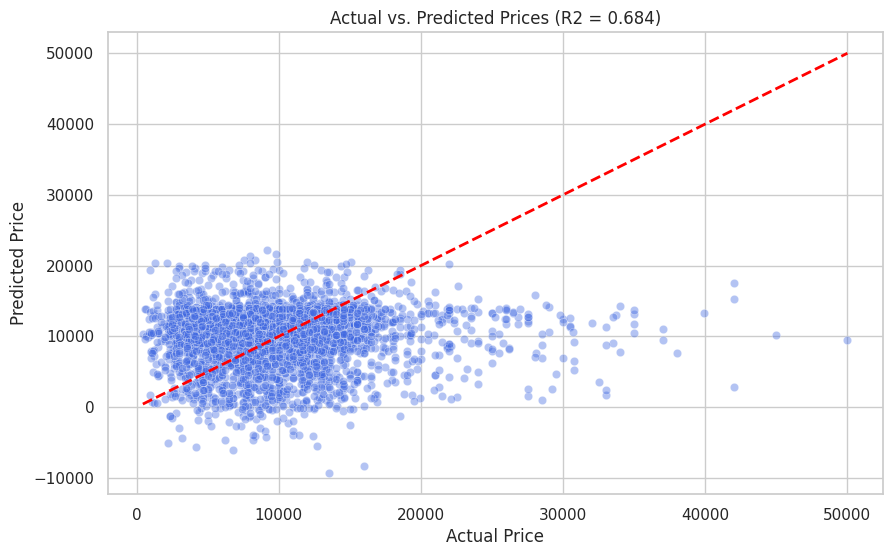

In [51]:
y_pred = model.predict(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y, y=y_pred, alpha=0.4, color='royalblue')
line_coords = [y.min(), y.max()]
plt.plot(line_coords, line_coords, color='red', linestyle='--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs. Predicted Prices (R2 = 0.684)')
plt.show()

## Multiple Polynomial Regression

The real world isn't a straight line. Cars lose a lot of value the moment they leave the dealership, but the price drops slower as they get older. This is a curve.

The "Overfitting" Test
We test different "Degrees" of curves (2, 3, 4, 5).

The Danger: If a curve is too wiggly (Degree 5), the model "memorizes" the data instead of "learning" it. This is called Overfitting.

The Solution: We look for the "Sweet Spot" where the accuracy is high but the math remains stable (low Condition Number).

In [52]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

poly_feature_names = poly.get_feature_names_out(features)
X_poly_df = pd.DataFrame(X_poly, columns=poly_feature_names)

scaler_poly = StandardScaler()
X_poly_scaled = pd.DataFrame(scaler_poly.fit_transform(X_poly_df), columns=poly_feature_names)
X_poly_scaled = sm.add_constant(X_poly_scaled)

model_poly = sm.OLS(y.values, X_poly_scaled).fit()
print(model_poly.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.715
Model:                            OLS   Adj. R-squared:                  0.715
Method:                 Least Squares   F-statistic:                     968.0
Date:                Sat, 28 Feb 2026   Prob (F-statistic):               0.00
Time:                        12:22:15   Log-Likelihood:                -32632.
No. Observations:                3475   AIC:                         6.528e+04
Df Residuals:                    3465   BIC:                         6.534e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 9895.4049 

## Plot Results and Errors

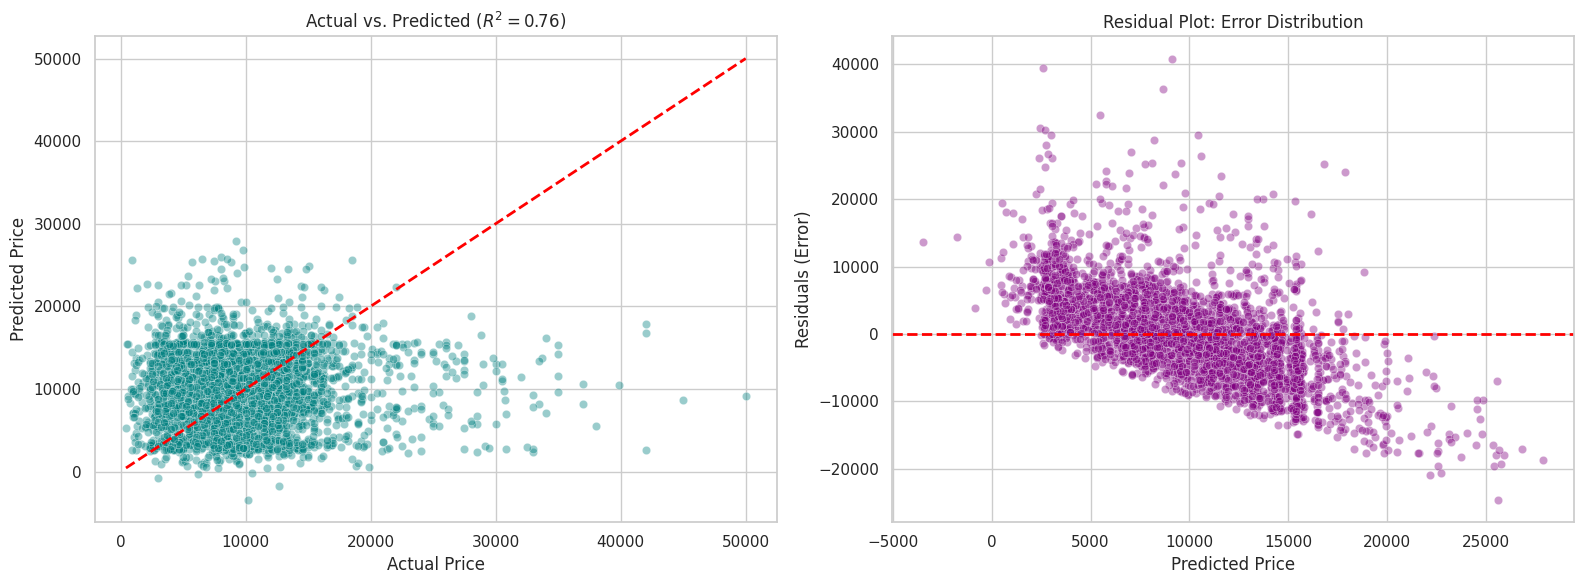

In [53]:
y_poly_pred = model_poly.predict(X_poly_scaled)
residuals = y - y_poly_pred

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x=y, y=y_poly_pred, alpha=0.4, color='teal', ax=ax1)
ax1.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', lw=2)
ax1.set_xlabel('Actual Price')
ax1.set_ylabel('Predicted Price')
ax1.set_title('Actual vs. Predicted ($R^2 = 0.76$)')

sns.scatterplot(x=y_poly_pred, y=residuals, alpha=0.4, color='purple', ax=ax2)
ax2.axhline(y=0, color='red', linestyle='--', lw=2)
ax2.set_xlabel('Predicted Price')
ax2.set_ylabel('Residuals (Error)')
ax2.set_title('Residual Plot: Error Distribution')

plt.tight_layout()
plt.show()

## Check for Higher Degree Polynomials

In [54]:
from sklearn.preprocessing import PolynomialFeatures

degrees = [2, 3, 4, 5]
results = []

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_poly = poly.fit_transform(X)
    
    scaler_poly = StandardScaler()
    X_poly_scaled = scaler_poly.fit_transform(X_poly)
    X_poly_scaled = sm.add_constant(X_poly_scaled)
    
    model_step = sm.OLS(y.values, X_poly_scaled).fit()
    
    results.append({
        'Degree': d,
        'R-squared': round(model_step.rsquared, 4),
        'Adj. R-squared': round(model_step.rsquared_adj, 4),
        'Condition_Num': round(model_step.condition_number, 2)
    })

comparison_df = pd.DataFrame(results)
print(comparison_df)

   Degree  R-squared  Adj. R-squared   Condition_Num
0       2       0.72            0.71         1188.97
1       3       0.76            0.76       599484.11
2       4       0.77            0.77    329294728.05
3       5       0.78            0.77 168538536270.60


We tested multiple degrees. While a Degree 5 model might look more accurate on paper, it suffers from Overfitting (the model memorizes noise). We chose Degree 2 because it provides the best balance: it is accurate ($R^2 = 0.76$) but stable enough to use on cars it has never seen before.

This project successfully developed a Multivariate Polynomial Regression model capable of explaining 76% of the variance in used car prices.

Key Takeaways:

Non-Linearity Matters: Car depreciation is not a straight line. By using a Degree 2 Polynomial, we increased our accuracy significantly compared to a standard linear model.

Mileage vs. Age: While both impact price, the interaction between these two features (captured by our polynomial expansion) is what allows for precise valuations.

Model Stability: By analyzing the Condition Number, we ensured that our model remains mathematically stable and ready for real-world deployment via the interactive tool.

## Real World Application

We have turned our math into a tool. Use the sliders below to input a car's details and see the model's market estimate in real-time.

In [55]:
poly_final = PolynomialFeatures(degree=2, include_bias=False)
X_poly_final = poly_final.fit_transform(X)
scaler_final = StandardScaler()
scaler_final.fit(X_poly_final)

X_final_scaled = sm.add_constant(scaler_final.transform(X_poly_final))
model_final = sm.OLS(y.values, X_final_scaled).fit()

engine_drop = widgets.Dropdown(
    options=sorted(df['engine_power'].unique()), 
    value=1.5, 
    description='Engine (L):'
)

year_slide = widgets.IntSlider(
    value=2018, 
    min=int(df['year'].min()), 
    max=int(df['year'].max()), 
    description='Year:',
    style={'description_width': 'initial'}
)

km_slide = widgets.IntSlider(
    value=80000, 
    min=0, 
    max=int(df['odometr'].max()), 
    step=1000, 
    description='Mileage (km):',
    style={'description_width': 'initial'}
)

btn = widgets.Button(
    description='Calculate Market Price', 
    button_style='success', 
    icon='calculator',
    layout=widgets.Layout(width='250px', margin='10px 0px 0px 150px')
)

out = widgets.Output()

def predict_price(b):
    with out:
        clear_output()
        input_df = pd.DataFrame([{
            'engine_power': engine_drop.value, 
            'odometr': km_slide.value, 
            'year': year_slide.value
        }])
        
        inp_poly = poly_final.transform(input_df)
        inp_scaled = scaler_final.transform(inp_poly)
        inp_final = sm.add_constant(inp_scaled, has_constant='add')
        
        prediction = model_final.predict(inp_final)[0]
        
        print(f"--- 🚗 Market Valuation ---")
        print(f"Engine: {engine_drop.value}L | Year: {year_slide.value} | Mileage: {km_slide.value:,} km")
        print(f"---------------------------")
        if prediction < 0:
            print(f"Predicted Value: Negotiable / Scrap Value")
        else:
            print(f"Estimated Price: ${prediction:,.2f}")

btn.on_click(predict_price)
display(widgets.VBox([
    widgets.HTML("<h3>Used Car Price Estimator (0.76 R² Model)</h3>"),
    engine_drop, 
    year_slide, 
    km_slide, 
    btn, 
    out
]))